In [1]:
import os
import io
import json
import time
import random
import shutil
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

import requests

from PIL import Image
import openslide

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.applications import EfficientNetB0

from idc_index import index

from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
# Install IDC index and other dependencies
!pip install idc-index openslide-bin openslide-python pillow tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 102.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 13.5 MB/s eta 0:00:00


In [3]:
CACHE_PATH = "ffpe_series.csv"

if os.path.exists(CACHE_PATH):
    ffpe_series = pd.read_csv(CACHE_PATH)
else:
    client = index.IDCClient()
    ffpe_series = client.sql_query("""
        SELECT
            PatientID,
            SeriesInstanceUID,
            SeriesDescription,
            series_size_MB,
            series_aws_url
        FROM index
        WHERE collection_id = 'tcga_hnsc'
        AND Modality = 'SM'
        AND SeriesDescription = 'FFPE HE TP DX1'
    """)
    ffpe_series.to_csv(CACHE_PATH, index=False)

print(f"Slides: {len(ffpe_series)}")
print(f"Patients: {ffpe_series['PatientID'].nunique()}")

Slides: 450
Patients: 450


In [4]:
def fetch_gdc_cases():
    url = "https://api.gdc.cancer.gov/cases"

    params = {
        "filters": '{"op":"=","content":{"field":"project.project_id","value":"TCGA-HNSC"}}',
        "fields": ",".join([
            "submitter_id",
            "diagnoses.tissue_or_organ_of_origin",
            "diagnoses.ajcc_pathologic_stage",
            "diagnoses.tumor_grade",
        ]),
        "format": "JSON",
        "size": "2000",
        "expand": "diagnoses"
    }

    for _ in range(3):
        r = requests.get(url, params=params)
        if r.status_code == 200:
            return r.json()
        time.sleep(2)

    raise Exception("Failed API request")

gdc_full = fetch_gdc_cases()
print(f"Cases fetched: {len(gdc_full['data']['hits'])}")

Cases fetched: 528


In [5]:
records = []

for case in gdc_full['data']['hits']:
    pid = case.get('submitter_id')

    for diag in case.get('diagnoses', []):
        if not diag.get('diagnosis_is_primary_disease', False):
            continue

        records.append({
            'PatientID': pid,
            'site': diag.get('tissue_or_organ_of_origin'),
            'stage': diag.get('ajcc_pathologic_stage'),
            'grade': diag.get('tumor_grade'),
        })

clinical_df = pd.DataFrame(records)
clinical_df['site'] = clinical_df['site'].str.strip()

print(clinical_df['site'].value_counts())

site
Tongue, NOS                                           131
Larynx, NOS                                           118
Overlapping lesion of lip, oral cavity and pharynx     70
Floor of mouth, NOS                                    55
Tonsil, NOS                                            42
Base of tongue, NOS                                    25
Mouth, NOS                                             23
Cheek mucosa                                           19
Oropharynx, NOS                                        11
Hypopharynx, NOS                                        8
Gum, NOS                                                8
Hard palate                                             3
Lip, NOS                                                3
Lower gum                                               2
Anterior floor of mouth                                 2
Mandible                                                1
Supraglottis                                            1
Palate, N

In [6]:
SITE_MAP = {
    'Base of tongue, NOS': 'Oropharynx',
    'Tonsil, NOS': 'Oropharynx',
    'Oropharynx, NOS': 'Oropharynx',
    'Anterior wall of nasopharynx': 'Oropharynx',
    'Posterior wall of oropharynx': 'Oropharynx',
    'Lateral wall of oropharynx': 'Oropharynx',
    'Anterior surface of epiglottis': 'Oropharynx',

    'Floor of mouth, NOS': 'Oral Cavity',
    'Tongue, NOS': 'Oral Cavity',
    'Oral tongue': 'Oral Cavity',
    'Gum, NOS': 'Oral Cavity',
    'Palate, NOS': 'Oral Cavity',
    'Oral cavity, NOS': 'Oral Cavity',
    'Lip, NOS': 'Oral Cavity',
    'Hard palate': 'Oral Cavity',
    'Cheek mucosa': 'Oral Cavity',
    'Retromolar area': 'Oral Cavity',
    'Mouth, NOS': 'Oral Cavity',

    'Larynx, NOS': 'Larynx',
    'Glottis': 'Larynx',
    'Supraglottis': 'Larynx',
    'Subglottis': 'Larynx',
    'Anterior commissure of larynx': 'Larynx',

    'Hypopharynx, NOS': 'Hypopharynx',
    'Pyriform sinus': 'Hypopharynx',
    'Posterior pharyngeal wall': 'Hypopharynx',
    'Postcricoid region': 'Hypopharynx',
}

clinical_df['subsite'] = clinical_df['site'].map(SITE_MAP)

mapped = clinical_df.dropna(subset=['subsite'])

print(mapped['subsite'].value_counts())

subsite
Oral Cavity    244
Larynx         119
Oropharynx      79
Hypopharynx      8
Name: count, dtype: int64


In [7]:
final_df = mapped.merge(
    ffpe_series[['PatientID','SeriesInstanceUID','series_size_MB','series_aws_url']],
    on='PatientID',
    how='inner'
)

final_df = final_df.drop_duplicates(subset=['SeriesInstanceUID'])

SUBSITE_TO_INT = {'Oral Cavity':0,'Larynx':1,'Oropharynx':2,'Hypopharynx':3}
final_df['subsite_label'] = final_df['subsite'].map(SUBSITE_TO_INT)

print(final_df['subsite'].value_counts())

final_df.head()

subsite
Oral Cavity    222
Larynx         106
Oropharynx      51
Hypopharynx      7
Name: count, dtype: int64


,PatientID,site,stage,grade,subsite,SeriesInstanceUID,series_size_MB,series_aws_url,subsite_label
0,TCGA-BB-4227,"Hypopharynx, NOS",Stage IVA,G2,Hypopharynx,1.3.6.1.4.1.5962.99.1.1600394021.179938475.163...,210.809916,s3://idc-open-data/8b91fcbe-e1d7-44bc-94a8-734...,3
1,TCGA-BB-4228,"Base of tongue, NOS",Stage III,GX,Oropharynx,1.3.6.1.4.1.5962.99.1.1585283019.627256364.163...,105.542112,s3://idc-open-data/7c8bddb1-af8f-4727-bc6d-f35...,2
2,TCGA-BA-4075,"Tongue, NOS",Stage III,G2,Oral Cavity,1.3.6.1.4.1.5962.99.1.1601894574.2140212515.16...,536.267024,s3://idc-open-data/ca0b3873-bf20-4fdb-861e-f5e...,0
3,TCGA-CN-6997,"Larynx, NOS",Stage IVA,G3,Larynx,1.3.6.1.4.1.5962.99.1.1600622464.225473974.163...,188.862050,s3://idc-open-data/655df2bf-4682-4bb6-b040-613...,1
4,TCGA-DQ-5629,"Larynx, NOS",None,G2,Larynx,1.3.6.1.4.1.5962.99.1.1556493448.2075633986.16...,2218.343284,s3://idc-open-data/d7126a50-dc90-4c8e-bd41-6e4...,1


In [8]:
SAMPLES_PER_CLASS = 20  # adjust as needed

sampled_df = (
    final_df
    .groupby('subsite', group_keys=False)
    .apply(lambda x: x.sample(min(len(x), SAMPLES_PER_CLASS), random_state=42))
)

print(sampled_df['subsite'].value_counts())
print("Estimated size (GB):", sampled_df['series_size_MB'].sum() / 1024)

subsite
Larynx         20
Oral Cavity    20
Oropharynx     20
Hypopharynx     7
Name: count, dtype: int64
Estimated size (GB): 50.854985984375


/tmp/ipykernel_5642/727107483.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), SAMPLES_PER_CLASS), random_state=42))


In [9]:
OUTPUT_DIR = "tiles"
WSI_DIR = "wsi"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(WSI_DIR, exist_ok=True)

TILE_SIZE = 224
MAX_TILES_PER_SLIDE = 20

In [10]:
def is_informative(tile, threshold=220):
    tile_np = np.array(tile.convert('RGB'))  # convert PIL → numpy first
    return tile_np.mean() < threshold


def tile_slide(slide_path, label, slide_id):
    try:
        slide = openslide.OpenSlide(slide_path)
    except Exception as e:
        print(f"  OpenSlide failed for {slide_id}: {e}")
        return

    width, height = slide.dimensions
    class_dir = os.path.join(OUTPUT_DIR, str(label))
    os.makedirs(class_dir, exist_ok=True)

    rng   = np.random.RandomState(42)
    count = 0
    max_x = max(1, width  - TILE_SIZE)
    max_y = max(1, height - TILE_SIZE)
    max_attempts = MAX_TILES_PER_SLIDE * 10
    attempts = 0

    # Random sampling instead of grid — more diverse patches
    while count < MAX_TILES_PER_SLIDE and attempts < max_attempts:
        x = int(rng.randint(0, max_x))
        y = int(rng.randint(0, max_y))

        tile = slide.read_region(
            (x, y), 0, (TILE_SIZE, TILE_SIZE)
        ).convert('RGB')

        if is_informative(tile):
            tile.save(f"{class_dir}/{slide_id}_{count}.jpg", quality=90)
            count += 1

        attempts += 1

    slide.close()

In [11]:
client = index.IDCClient()

for _, row in tqdm(sampled_df.iterrows(), total=len(sampled_df)):
    slide_id  = row['SeriesInstanceUID']
    label     = row['subsite_label']
    slide_dir = os.path.join(WSI_DIR, slide_id)
    os.makedirs(slide_dir, exist_ok=True)

    try:
        client.download_dicom_series(
            seriesInstanceUID=slide_id,
            downloadDir=slide_dir,
            quiet=True,
            show_progress_bar=False
        )

        # Find downloaded file — IDC stores in nested dirs per dirTemplate
        # pattern: WSI_DIR/{slide_id}/tcga_hnsc/{PatientID}/{StudyUID}/SM_{SeriesUID}/
        slide_path = None
        for root, dirs, files in os.walk(slide_dir):
            for file in files:
                if file.endswith((".svs", ".tif", ".tiff", ".dcm")):
                    slide_path = os.path.join(root, file)
                    break
            if slide_path:
                break

        if slide_path is None:
            print(f"No slide file found for {slide_id}")
            shutil.rmtree(slide_dir)
            continue

        # Extract tiles
        tile_slide(slide_path, label, slide_id)

        # Delete full slide immediately to preserve disk space
        shutil.rmtree(slide_dir)

    except Exception as e:
        print(f"Error with {slide_id}: {e}")
        if os.path.exists(slide_dir):
            shutil.rmtree(slide_dir)

100%|██████████| 67/67 [25:38<00:00, 22.96s/it]


In [12]:
count = sum(len(files) for _, _, files in os.walk(OUTPUT_DIR))
print("Total tiles:", count)

Total tiles: 1331


In [13]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    OUTPUT_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    OUTPUT_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

Found 1331 files belonging to 4 classes.
Using 1065 files for training.
Found 1331 files belonging to 4 classes.
Using 266 files for validation.


In [24]:
base_model = EfficientNetB0(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [25]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 53s 788ms/step - accuracy: 0.3756 - loss: 1.3172 - val_accuracy: 0.4436 - val_loss: 1.2035
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.5634 - loss: 1.0564 - val_accuracy: 0.4812 - val_loss: 1.1414
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.6216 - loss: 0.9439 - val_accuracy: 0.4887 - val_loss: 1.1333
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.6845 - loss: 0.8253 - val_accuracy: 0.5526 - val_loss: 1.0603
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.7192 - loss: 0.7465 - val_accuracy: 0.5338 - val_loss: 1.1119
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.7840 - loss: 0.6410 - val_accuracy: 0.5639 - val_loss: 1.0618
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.7878 - loss: 0.5932 - val_accuracy: 0.5414 - val_loss: 1.0615
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.8207 - loss: 0.5420 - val_accuracy: 0.5489 -

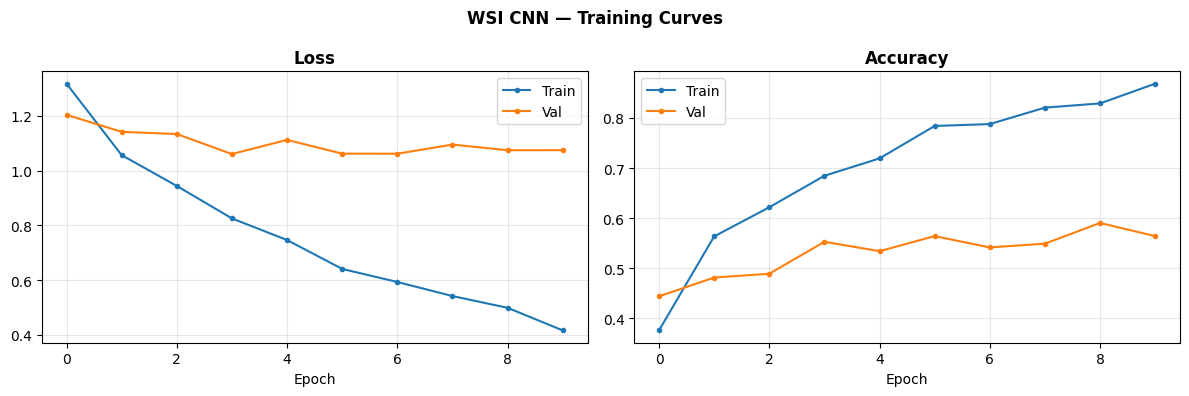

In [26]:
SUBSITE_NAMES = ['Oral Cavity', 'Larynx', 'Oropharynx', 'Hypopharynx']

# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='Train', marker='o', markersize=3)
axes[0].plot(history.history['val_loss'], label='Val',   marker='o', markersize=3)
axes[0].set_title('Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Train', marker='o', markersize=3)
axes[1].plot(history.history['val_accuracy'], label='Val',   marker='o', markersize=3)
axes[1].set_title('Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('WSI CNN — Training Curves', fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
# ── Predictions on validation set ────────────────────────────────────────────
y_true, y_pred, y_prob = [], [], []

for imgs, labels in val_ds:
    probs = model.predict(imgs, verbose=0)
    y_pred.extend(np.argmax(probs, axis=1))
    y_prob.extend(probs)
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

# ── Classification report ─────────────────────────────────────────────────────
print('=' * 55)
print('  WSI CNN — Subsite Classification (Val Set)')
print('=' * 55)
print(classification_report(y_true, y_pred, target_names=SUBSITE_NAMES))

  WSI CNN — Subsite Classification (Val Set)
              precision    recall  f1-score   support

 Oral Cavity       0.62      0.54      0.58        72
      Larynx       0.60      0.62      0.61        81
  Oropharynx       0.56      0.59      0.58        83
 Hypopharynx       0.36      0.40      0.38        30

    accuracy                           0.56       266
   macro avg       0.54      0.54      0.54       266
weighted avg       0.57      0.56      0.56       266



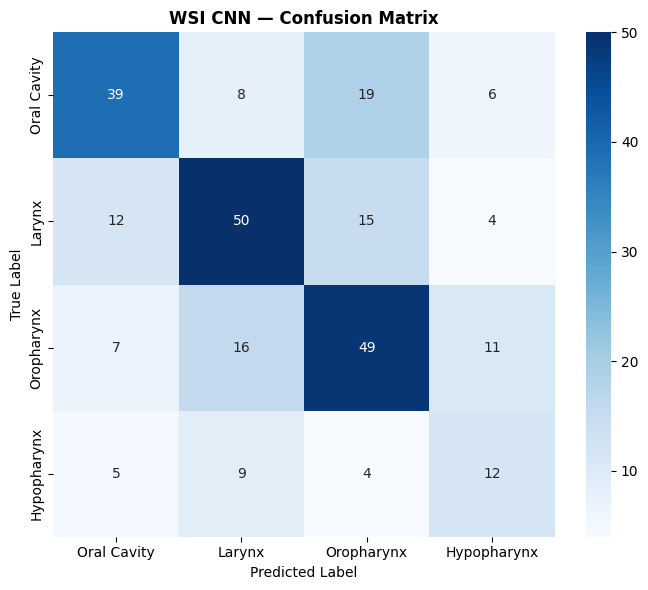

In [28]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=SUBSITE_NAMES,
    yticklabels=SUBSITE_NAMES
)
plt.title('WSI CNN — Confusion Matrix', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [29]:
# ── Per-class accuracy ────────────────────────────────────────────────────────
print('Per-class accuracy:')
for i, name in enumerate(SUBSITE_NAMES):
    mask     = y_true == i
    if mask.sum() == 0:
        continue
    class_acc = (y_pred[mask] == i).mean()
    print(f'  {name:15s}: {class_acc:.4f}  ({mask.sum()} samples)')

Per-class accuracy:
  Oral Cavity    : 0.5417  (72 samples)
  Larynx         : 0.6173  (81 samples)
  Oropharynx     : 0.5904  (83 samples)
  Hypopharynx    : 0.4000  (30 samples)


In [31]:
# ── Build embedding extractor ─────────────────────────────────────────────────
# EfficientNetB0 Sequential: iterate layers to find GAP output
inp = tf.keras.Input(shape=(224, 224, 3))
x   = inp
for layer in model.layers:
    x = layer(x)
    if layer.__class__.__name__ == 'GlobalAveragePooling2D':
        embedding_output = x
        break

embedding_model = tf.keras.Model(inputs=inp, outputs=embedding_output)

# Verify embedding shape
for imgs, labels in val_ds.take(1):
    test_emb = embedding_model.predict(imgs, verbose=0)
    print(f"Embedding shape per batch: {test_emb.shape}")  # expect (32, 1280)
    break

# ── Extract embeddings from validation set ────────────────────────────────────
all_embeddings, all_labels_out = [], []

for imgs, labels in val_ds:
    embs = embedding_model.predict(imgs, verbose=0)
    all_embeddings.extend(embs)
    all_labels_out.extend(labels.numpy())

embeddings_array = np.array(all_embeddings)
labels_array     = np.array(all_labels_out)

np.save('wsi_embeddings.npy',        embeddings_array)
np.save('wsi_embeddings_labels.npy', labels_array)
print(f'Embeddings shape : {embeddings_array.shape}')  # (N, 1280)
print(f'Labels shape     : {labels_array.shape}')

# ── Save full model ───────────────────────────────────────────────────────────
model.save('wsi_baseline_efficientnet.keras')
embedding_model.save('wsi_embedding_model.keras')
print('Models saved:')
print('  wsi_baseline_efficientnet.keras  — full classifier')
print('  wsi_embedding_model.keras        — embedding extractor for fusion')

# ── Baseline summary ──────────────────────────────────────────────────────────
acc = accuracy_score(y_true, y_pred)
f1  = f1_score(y_true, y_pred, average='weighted')

print('\n' + '='*55)
print('  IMAGING BASELINE SUMMARY')
print('  (Benchmark for multimodal fusion)')
print('='*55)
print(f'  Task       : Tumor Subsite Classification')
print(f'  Dataset    : TCGA-HNSC (FFPE H&E WSI patches)')
print(f'  Model      : EfficientNetB0 (frozen) + FC head')
print(f'  Embedding  : 1280-dim GAP vector')
print(f'  Tiles      : 1331 across 67 slides')
print(f'  Accuracy   : {acc:.4f}')
print(f'  F1 Score   : {f1:.4f}  (weighted)')
print('='*55)
print('\nOutputs for fusion stage:')
print('  wsi_embeddings.npy        — image feature vectors')
print('  wsi_embeddings_labels.npy — corresponding labels')
print('  wsi_embedding_model.keras — reload to embed new images')

Embedding shape per batch: (32, 1280)
Embeddings shape : (266, 1280)
Labels shape     : (266,)
Models saved:
  wsi_baseline_efficientnet.keras  — full classifier
  wsi_embedding_model.keras        — embedding extractor for fusion

  IMAGING BASELINE SUMMARY
  (Benchmark for multimodal fusion)
  Task       : Tumor Subsite Classification
  Dataset    : TCGA-HNSC (FFPE H&E WSI patches)
  Model      : EfficientNetB0 (frozen) + FC head
  Embedding  : 1280-dim GAP vector
  Tiles      : 1331 across 67 slides
  Accuracy   : 0.5639
  F1 Score   : 0.5649  (weighted)

Outputs for fusion stage:
  wsi_embeddings.npy        — image feature vectors
  wsi_embeddings_labels.npy — corresponding labels
  wsi_embedding_model.keras — reload to embed new images
